In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import html
import random
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder

# Text preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

In [3]:
class DataPreprocessor:
    def __init__(self):
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        self.tokenizer = None
        
    def clean_text(self, text):
        if pd.isna(text):
            return ""
        # Convert to string and lowercase
        text = str(text).lower()
        text = html.unescape(text)
        # Remove HTML tags
        text = re.sub(r'<[^>]+>', '', text)
        # Remove URLs
        text = re.sub(r'http\S+|www.\S+', '', text)
        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # Remove extra whitespaces
        text = re.sub(r'\s+', ' ', text).strip()
        
        return text
    
    def tokenize_and_lemmatize(self, text):
        tokens = word_tokenize(text)
        # Remove stopwords and lemmatize
        tokens = [
            self.lemmatizer.lemmatize(token) 
            for token in tokens 
            if token not in self.stop_words and len(token) > 2
        ]
        return ' '.join(tokens)
    
    def preprocess_dataset(self, df, text_column='review', label_column='sentiment'): 
        print("Starting data preprocessing")
        df.drop_duplicates(subset=text_column, inplace=True)
        # Clean text
        df['cleaned_text'] = df[text_column].apply(self.clean_text)
        # Tokenize and lemmatize
        df['processed_text'] = df['cleaned_text'].apply(self.tokenize_and_lemmatize)
        # Remove empty reviews
        df = df[df['processed_text'].str.len() > 0].reset_index(drop=True)
        # Encode labels
        le = LabelEncoder()
        df['label'] = le.fit_transform(df[label_column])
        print(f"Preprocessing complete. Dataset shape: {df.shape}")
        return df, le


In [4]:
print("Loading IMDB dataset...")
#loading IMDB dataset
df = pd.read_csv('IMDB_Dataset.csv')
    
print(f"Dataset shape: {df.shape}")
print(f"Sentiment distribution:\n{df['sentiment'].value_counts()}")
    
# Initialize preprocessor
preprocessor = DataPreprocessor()
    
# Preprocess data
df_processed, label_encoder = preprocessor.preprocess_dataset(df)

Loading IMDB dataset...
Dataset shape: (50000, 2)
Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Starting data preprocessing
Preprocessing complete. Dataset shape: (49582, 5)


In [5]:
import pickle
with open('imdb_processed.pkl', 'wb') as f:
    pickle.dump((df_processed, label_encoder), f)

In [6]:
with open('imdb_processed.pkl', 'rb') as f:
    df_processed, label_encoder = pickle.load(f)

In [7]:
df_processed.head()

,review,sentiment,cleaned_text,processed_text,label
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...,one reviewer mentioned watching episode youll ...,1
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically theres a family where a little boy j...,basically there family little boy jake think t...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love in the time of money is a ...,petter matteis love time money visually stunni...,1


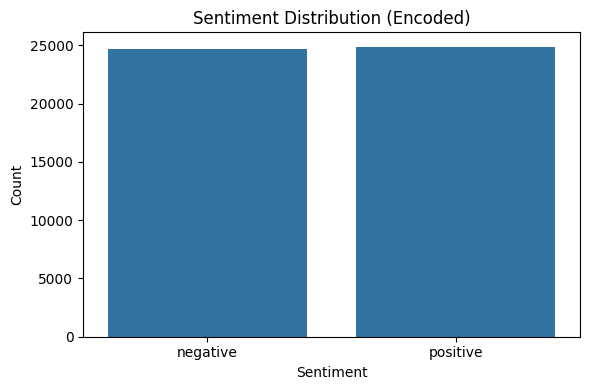

In [8]:
# Plot sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df_processed, x='label')
plt.title("Sentiment Distribution (Encoded)")
plt.xticks(ticks=[0, 1], labels=label_encoder.classes_)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("sentiment_distribution")
plt.show()


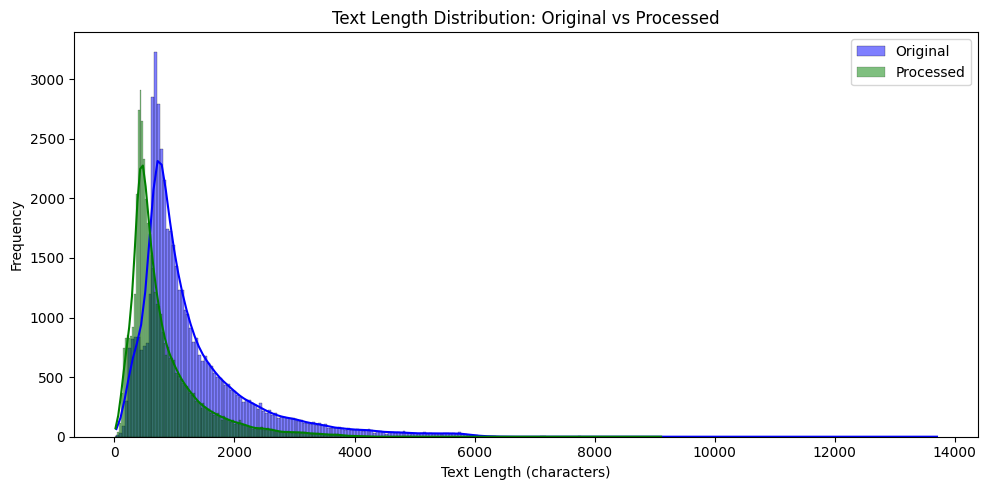

In [9]:
# Add length columns
df_processed['original_length'] = df['review'].apply(lambda x: len(str(x)))
df_processed['processed_length'] = df_processed['processed_text'].apply(len)

# Plot comparison
plt.figure(figsize=(10,5))
sns.histplot(df_processed['original_length'], color='blue', label='Original', kde=True)
sns.histplot(df_processed['processed_length'], color='green', label='Processed', kde=True)
plt.legend()
plt.title("Text Length Distribution: Original vs Processed")
plt.xlabel("Text Length (characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Text_Length_Distribution")
plt.show()


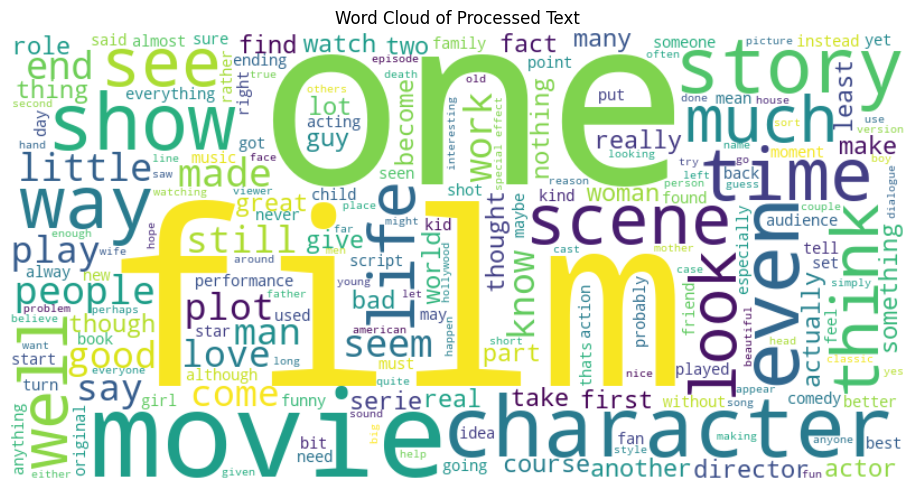

In [10]:
from wordcloud import WordCloud

# Generate word cloud
text = ' '.join(df_processed['processed_text'].values)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Processed Text")
plt.tight_layout()
plt.savefig("word_cloud")
plt.show()
